# During this notebook, we are comparing all models including machine learning and deep learning 

In order to compare these model, we need to wrap deep learning models in some to class in order to obtain a similar behavior to ml models from sklearn i.e. to have predict and fit methods 

In [5]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import MinMaxScaler
import numpy as np

First create our deep learning models

In [6]:
class RecurrentNN(BaseEstimator, RegressorMixin):
    def __init__(self, epochs, lr, batch_size, hidden_size, input_size):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.input_size = input_size

    def _build_model(self):
        class RNN(nn.Module):
            def __init__(self, input_size, hidden_size):
                super().__init__()
                self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
                self.fc = nn.Linear(hidden_size, 1)
            def forward(self, x):
                out, _ = self.rnn(x)  ## receives as input (Batch, Window, Input_size) => (Batch, Window, Hidden_size)
                return self.fc(out[:, -1, :]).squeeze(-1)
        return RNN(self.input_size, self.hidden_size)

    def fit(self, X_train, y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        self.scaler_x_ = MinMaxScaler(feature_range=(0,1))
        self.scaler_y_ = MinMaxScaler(feature_range=(0,1))
        X_scaled = self.scaler_x_.fit_transform(X)
        y_scaled = self.scaler_y_.fit_transform(y.reshape(-1, 1)).flatten()

    
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(-1)
        y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

        
        dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        
        self.model_ = self._build_model()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

    
        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                optimizer.step()
        return self

    def predict(self, X):
        X = np.array(X)
        X_scaled = self.scaler_x_.transform(X)  
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(-1)

        self.model_.eval()
        with torch.no_grad():
            y_pred_scaled = self.model_(X_tensor).numpy()
        y_pred = self.scaler_y_.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        return y_pred

In [7]:
class RecurrentNN_two_layers(BaseEstimator, RegressorMixin):
    def __init__(self, epochs, lr, batch_size, hidden_size_1, hidden_size_2, input_size):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.hidden_size_1 = hidden_size_1
        self.hidden_size_2 = hidden_size_2
        self.input_size = input_size

    def _build_model(self):
        class RNN(nn.Module):
            def __init__(self, input_size, hidden_size_1, hidden_size_2):
                super().__init__()
                self.rnn_1 = nn.RNN(input_size, hidden_size_1, batch_first=True) ## receives as input (Batch, Window, Input_size) => (Batch, Window, Hidden_size)
                self.rnn_2 = nn.RNN(hidden_size_1, hidden_size_2, batch_first=True)
                self.fc = nn.Linear(hidden_size_2, 1)
            def forward(self, x):
                x, _ = self.rnn_1(x) 
                x, _ = self.rnn_2(x)
                return self.fc(x[:, -1, :]).squeeze(-1)
        return RNN(self.input_size, self.hidden_size_1, self.hidden_size_2)

    def fit(self, X_train, y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        
        self.scaler_x_ = MinMaxScaler(feature_range=(0,1))
        self.scaler_y_ = MinMaxScaler(feature_range=(0,1))
        X_scaled = self.scaler_x_.fit_transform(X)
        y_scaled = self.scaler_y_.fit_transform(y.reshape(-1, 1)).flatten()

    
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(-1)
        y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

        
        dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        
        self.model_ = self._build_model()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

    
        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                optimizer.step()
        return self

    def predict(self, X):
        X = np.array(X)
        X_scaled = self.scaler_x_.transform(X)  
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(-1)

        self.model_.eval()
        with torch.no_grad():
            y_pred_scaled = self.model_(X_tensor).numpy()
        y_pred = self.scaler_y_.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        return y_pred

In [8]:
class MLP_two_layers(BaseEstimator, RegressorMixin):
    def __init__(self, epochs, lr, batch_size, hidden_size_1, hidden_size_2, in_features):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.hidden_size_1 = hidden_size_1
        self.hidden_size_2 = hidden_size_2
        self.in_features = in_features

    def _build_model(self):
        class Fully_Connected(nn.Module):
            def __init__(self, in_features, hidden_size_1, hidden_size_2):
                super().__init__()
                self.linear_1 = nn.Linear(in_features=in_features, out_features=hidden_size_1)
                self.linear_2 = nn.Linear(in_features=hidden_size_1, out_features=hidden_size_2)
                self.linear_3 = nn.Linear(in_features=hidden_size_2, out_features=1)
               
            def forward(self, x):
                x = torch.relu(self.linear_1(x))
                x = torch.relu(self.linear_2(x))
                x = self.linear_3(x)
                return x.squeeze(-1)
            
        return Fully_Connected(self.in_features, self.hidden_size_1, self.hidden_size_2)

    def fit(self, X_train, y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        
        self.scaler_x_ = MinMaxScaler(feature_range=(0,1))
        self.scaler_y_ = MinMaxScaler(feature_range=(0,1))
        X_scaled = self.scaler_x_.fit_transform(X)
        y_scaled = self.scaler_y_.fit_transform(y.reshape(-1, 1)).flatten()

    
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

        
        dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        
        self.model_ = self._build_model()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

    
        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                optimizer.step()
        return self

    def predict(self, X):
        X = np.array(X)
        X_scaled = self.scaler_x_.transform(X)  
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

        self.model_.eval()
        with torch.no_grad():
            y_pred_scaled = self.model_(X_tensor).numpy()
        y_pred = self.scaler_y_.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        return y_pred

In [9]:
class MLP_one_layer(BaseEstimator, RegressorMixin):
    def __init__(self, epochs, lr, batch_size, hidden_size, in_features):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.in_features = in_features

    def _build_model(self):
        class Fully_Connected(nn.Module):
            def __init__(self, in_features, hidden_size):
                super().__init__()
                self.linear_1 = nn.Linear(in_features=in_features, out_features=hidden_size)
                self.linear_2 = nn.Linear(in_features=hidden_size, out_features=1)
          
            def forward(self, x):
                x = torch.relu(self.linear_1(x))
                x = self.linear_2(x)
                return x.squeeze(-1)
            
        return Fully_Connected(in_features=self.in_features, hidden_size=self.hidden_size)

    def fit(self, X_train, y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        
        self.scaler_x_ = MinMaxScaler(feature_range=(0,1))
        self.scaler_y_ = MinMaxScaler(feature_range=(0,1))
        X_scaled = self.scaler_x_.fit_transform(X)
        y_scaled = self.scaler_y_.fit_transform(y.reshape(-1, 1)).flatten()

    
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

        
        dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        
        self.model_ = self._build_model()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

    
        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                optimizer.step()
        return self

    def predict(self, X):
        X = np.array(X)
        X_scaled = self.scaler_x_.transform(X)  
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

        self.model_.eval()
        with torch.no_grad():
            y_pred_scaled = self.model_(X_tensor).numpy()
        y_pred = self.scaler_y_.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        return y_pred

Let's compare the models 

In [1]:
import sys
import os

project_root = os.path.abspath("..") 
sys.path.append(project_root)

from scripts.compare_models import Models_Horizon

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline 

Define our parameters 

In [23]:
cut_point = 2290
test_size = 288 ## To work with TimeSeriesSplit
window_size = 6
horizon = 3
folds = 5
batch_size = 16 ## Just for nn 
lr = 0.01 
epochs = 300
metrics = [
    mean_squared_error, 
    mean_absolute_error, 
    mean_absolute_percentage_error
]
models = [
    Pipeline(steps=[('scaler', MinMaxScaler(feature_range=(0,1))), 
                     ('linear_regression', LinearRegression())]),
    MLP_one_layer(epochs=epochs, lr=lr, batch_size=batch_size, hidden_size=8, in_features=window_size),
    MLP_two_layers(epochs=epochs, lr=lr, batch_size=batch_size, hidden_size_1=16, hidden_size_2=8, in_features=window_size),
    RecurrentNN(epochs=epochs, lr=lr, batch_size=batch_size, hidden_size=8, input_size=1),
    RecurrentNN_two_layers(epochs=epochs, lr=lr, batch_size=batch_size, hidden_size_1=8, hidden_size_2=16, input_size=1)
]
model_names = [
    'LinearRegression',
    'MLP_one_layer', 
    'MLP_two_layers', 
    'RecurrentNN_one_layer', 
    'RecurrentNN_two_layers'
]

In [24]:
horizon_3 = Models_Horizon(cut_point=cut_point, test_size=test_size, window_size=window_size, horizon=horizon, 
                           folds=5, models=models, model_names=model_names, metrics=metrics)

In [25]:
result = horizon_3.test_models()

In [26]:
result.shape

(25, 15)

In [27]:
result

metric                 mse                                                     \
model     LinearRegression MLP_one_layer MLP_two_layers RecurrentNN_one_layer   
HUPA0004P        55.523421    125.430109     154.715680            285.917420   
HUPA0006P        50.017578   2380.500093    1066.803907            276.597499   
HUPA0007P       411.876662    468.448191     433.212894            430.987958   
HUPA0009P        15.030784     82.571950      83.930915            275.733691   
HUPA0005P        98.765939    115.802131     126.995016            124.030743   
HUPA0011P       135.823583    189.700548     235.458226            212.687639   
HUPA0003P       132.065859    188.043666     206.593253            147.727194   
HUPA0001P       266.458191    283.296780     326.093497            313.096751   
HUPA0010P        95.921505    140.529221     120.232113            149.972606   
HUPA0002P        38.986920     92.133654    1155.615352             70.620411   
HUPA0014P        52.148677    150.072459     242.486131            152.961988   
HUPA0015P        46.236279     78.458662     116.490370            133.022109   
HUPA0016P        59.820836    131.979149     193.763182            114.515724   
HUPA0017P        67.396896    145.507943     195.532355             99.360495   
HUPA0018P        56.615224    123.024766     264.236721            135.669075   
HUPA0021P        73.512327    103.254784     115.453776             93.095415   
HUPA0020P        48.642507    127.868799     116.365322             93.014711   
HUPA0024P        50.823299    188.797947     197.719417            145.366002   
HUPA0019P        92.877304    105.928459     108.483380            118.270680   
HUPA0023P        52.553932     91.742704      69.807093             92.173913   
HUPA0022P       123.785950    152.816478     162.379572            157.008018   
HUPA0025P        45.475262    104.619994     106.142294             69.561097   
HUPA0028P        73.783178    109.526241     121.691281            104.861276   
HUPA0026P        65.584740    309.052400     256.206225            771.234198   
HUPA0027P        55.570567     72.956968      72.245657             68.805455   

metric                                        mae                \
model     RecurrentNN_two_layers LinearRegression MLP_one_layer   
HUPA0004P             536.760119         4.838593      8.268846   
HUPA0006P            5982.256885         4.715611     24.567915   
HUPA0007P            3148.306759        13.461993     14.980099   
HUPA0009P            5510.130646         1.299976      6.947438   
HUPA0005P            6016.586545         6.896306      7.985929   
HUPA0011P             982.088347         7.677921      9.897662   
HUPA0003P             292.737955         7.033723      9.769429   
HUPA0001P             371.665447        10.893554     11.949735   
HUPA0010P             950.891594         4.621198      6.326589   
HUPA0002P            1400.968713         4.110123      7.534991   
HUPA0014P            1464.257399         4.475805     10.315165   
HUPA0015P            4778.927984         4.560707      6.739227   
HUPA0016P            1112.124088         5.055831      8.891554   
HUPA0017P           17003.164683         5.391994      9.531386   
HUPA0018P            1263.957111         4.983539      8.730174   
HUPA0021P             337.075101         5.581803      7.193614   
HUPA0020P            3263.997270         4.722876      8.672770   
HUPA0024P            1889.857504         4.657701     10.197585   
HUPA0019P             623.261492         6.430319      7.096536   
HUPA0023P             188.315472         4.915200      7.442244   
HUPA0022P             458.966326         7.088000      8.669135   
HUPA0025P            4578.435963         4.551411      7.728299   
HUPA0028P             119.525630         5.492119      8.022004   
HUPA0026P            8644.535735         4.788862     13.332281   
HUPA0027P            3103.137529         4.928036      6.044126   

me

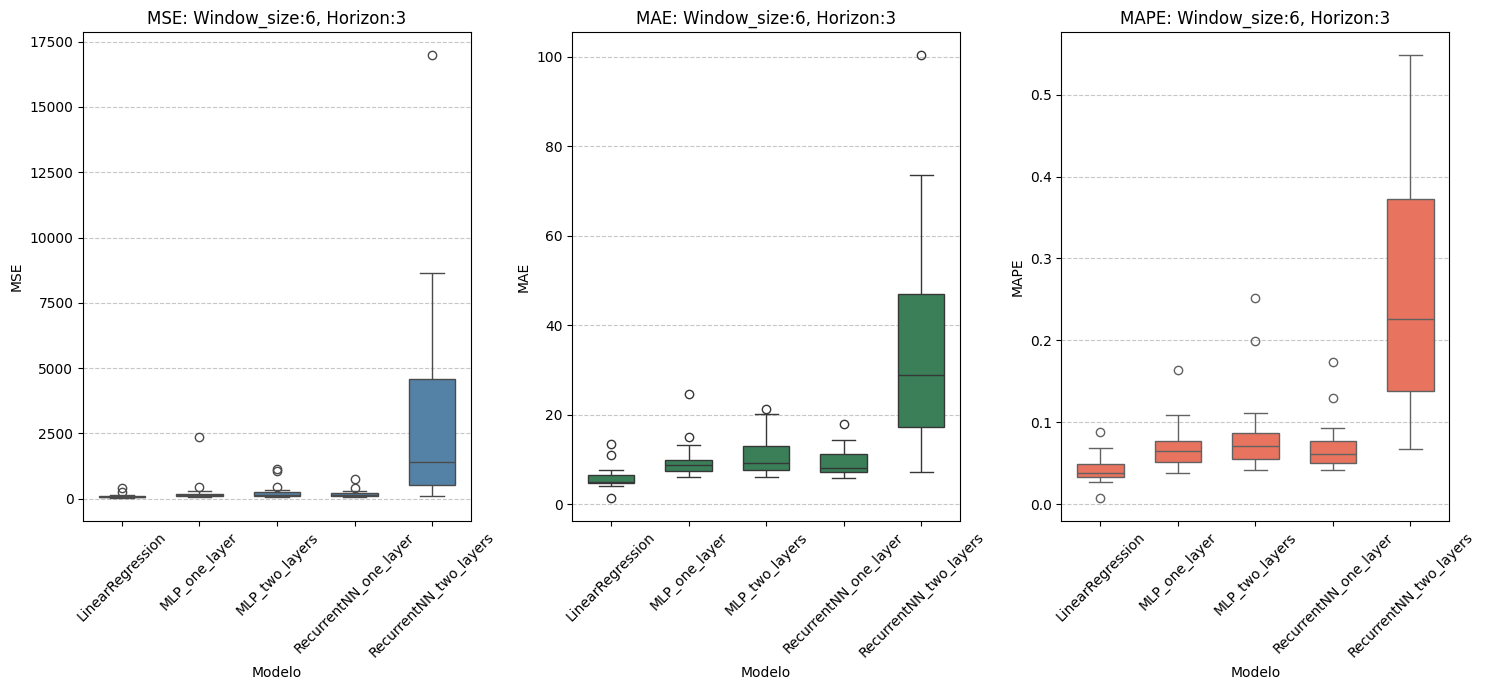

MSE
model  LinearRegression  MLP_one_layer  MLP_two_layers  RecurrentNN_one_layer  \
count         25.000000      25.000000       25.000000              25.000000   
mean          90.611897     242.482564      249.946145             185.451683   
std           83.092349     453.868078      273.043265             151.605167   
min           15.030784      72.956968       69.807093              68.805455   
25%           50.823299     104.619994      116.365322              99.360495   
50%           59.820836     127.868799      162.379572             135.669075   
75%           95.921505     188.043666      242.486131             212.687639   
max          411.876662    2380.500093     1155.615352             771.234198   

model  RecurrentNN_two_layers  
count               25.000000  
mean              2960.877292  
std               3734.217034  
min                119.525630  
25%                536.760119  
50%               1400.968713  
75%               4578.435963  
max       

In [28]:
horizon_3.visualize_model_comparison()